# Unidad 9 · El piloto de riesgo por dentro

**Qué vas a hacer:** reconstruir desde cero, con lo aprendido en las ocho unidades, cada pantalla del
piloto de riesgo, y comprobar que llegas a las mismas cifras que la app.

| Pantalla | Qué responde | Unidades |
|---|---|---|
| **Hoy** | cuánto tener en cripto y qué órdenes dar | 3, 4, 6 |
| **Tiempos duros** | cuánto perderías si se repitiera lo peor | 2, 8 |
| **La regla en el pasado** | qué habría pasado siguiendo la regla desde 2020 | 3, 6 |
| **Mi diario** | cuánto ha ganado o perdido tu cartera, sin contar ingresos | 2 |

La regla del piloto cabe en una línea:

$$\text{parte en cripto} = \min\left(\text{máximo},\ \frac{\text{objetivo}}{\text{volatilidad prevista}}\right) \times \text{freno}(\text{caída})$$

Con los valores de fábrica: objetivo 15 % (**Prudente**), máximo 100 %, volatilidad EWMA con λ = 0,94,
freno desde una caída del 10 %, banda del 5 % y un coste de 0,15 % por operación.

In [1]:
#@title Preparación: ejecuta esta celda primero (▶). Carga los precios de Binance.
# Es la misma en todos los cuadernos. Cómo se construye se explica en la Unidad 1.
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})

ACTIVOS = ["BTC", "ETH", "SOL"]        # las monedas de la cartera de ejemplo del piloto
COLORES = {"BTC": "#F7931A", "ETH": "#627EEA", "SOL": "#9945FF"}
DESDE = "2020-01-01"                    # el piloto también mira desde 2020
HASTA = "2026-09-26"                    # fija las cifras del texto; None = hasta ayer
ANUAL = 365                             # las criptos cotizan todos los días del año
API = "https://data-api.binance.vision/api/v3/klines"   # api.binance.com bloquea Colab


def descargar(simbolo, desde=DESDE):
    """Velas diarias YA CERRADAS de SIMBOLO/USDT en Binance, 1000 por petición."""
    inicio = int(pd.Timestamp(desde, tz="UTC").timestamp() * 1000)
    filas = []
    while True:
        r = requests.get(API, params={"symbol": f"{simbolo}USDT", "interval": "1d",
                                      "startTime": inicio, "limit": 1000}, timeout=30)
        r.raise_for_status()
        lote = r.json()
        filas += lote
        if len(lote) < 1000:
            break
        inicio = lote[-1][0] + 1                      # la página siguiente empieza tras la última vela
    crudo = pd.DataFrame([f[:7] for f in filas],
                         columns=["apertura_ms", "open", "high", "low", "close", "volume", "cierre_ms"])
    crudo = crudo[crudo["cierre_ms"] < pd.Timestamp.now(tz="UTC").timestamp() * 1000]
    df = pd.DataFrame({"fecha": pd.to_datetime(crudo["apertura_ms"], unit="ms", utc=True)})
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = crudo[c].astype(float).to_numpy()
    return df.drop_duplicates("fecha").reset_index(drop=True)


def velas(simbolo):
    """Velas diarias del periodo de estudio: del CSV si ya está, si no de Binance (y lo guarda)."""
    archivo = f"{simbolo}USDT_1d.csv"
    hoy = pd.Timestamp.now(tz="UTC").normalize()
    fin = pd.Timestamp(HASTA, tz="UTC") if HASTA else hoy - pd.Timedelta(days=1)
    df = None
    if os.path.exists(archivo):
        df = pd.read_csv(archivo)
        df["fecha"] = pd.to_datetime(df["fecha"], utc=True)
    if df is None or df["fecha"].max() < fin:
        try:
            df = descargar(simbolo)
            df.to_csv(archivo, index=False, date_format="%Y-%m-%dT%H:%M:%SZ")
        except requests.RequestException as e:
            if df is None:
                raise RuntimeError(f"No pude descargar {simbolo} de Binance ({e}). Sube {archivo} "
                                   "(carpeta de datos de respaldo del curso) y repite.") from None
            print(f"Aviso: sin conexión con Binance; {archivo} llega solo al {df['fecha'].max():%d-%m-%Y}.")
    df = df[(df["fecha"] >= pd.Timestamp(DESDE, tz="UTC")) & (df["fecha"] <= fin)]
    return df.set_index("fecha")


def cierres(activos=ACTIVOS):
    """Cierres diarios, una columna por moneda: la tabla con la que trabaja el piloto."""
    return pd.DataFrame({a: velas(a)["close"] for a in activos})


print(f"Listo. Periodo de estudio: del {DESDE} al {HASTA or 'día de ayer'}.")

Listo. Periodo de estudio: del 2020-01-01 al 2026-09-26.


## 1. La cartera y los datos

La cartera de ejemplo del manual: **0,05 BTC, 1,2 ETH, 10 SOL y 500 USDT**. La app la valora con el
precio de este momento; aquí, para que las cifras se puedan repetir, con el cierre del 26-09-2026.

In [2]:
AJUSTES = dict(objetivo=0.15, max_exposicion=1.0, banda=0.05, freno_inicio=0.10, freno_tope=0.25,
               freno_minimo=0.25, freno_ventana=180, minimo_orden=10.0, coste=0.0015, lam=0.94)
ESTABLES = {"USDT", "USDC", "FDUSD", "DAI"}                          # cuentan como efectivo
tenencias = {"BTC": 0.05, "ETH": 1.2, "SOL": 10.0, "USDT": 500.0}

precios_hist = cierres()                                              # cierres diarios desde 2020
cripto = pd.Series({a: u for a, u in tenencias.items() if a not in ESTABLES})
efectivo = sum(u for a, u in tenencias.items() if a in ESTABLES)
precio = precios_hist[cripto.index].iloc[-1]                          # «precio de ahora»
valor = cripto * precio
total = valor.sum() + efectivo
print(f"Total {total:,.2f} USDT: {valor.sum():,.2f} en cripto ({valor.sum() / total:.1%}) y {efectivo:,.2f} en efectivo")
valor.round(2)

Total 9,171.35 USDT: 8,671.35 en cripto (94.5%) y 500.00 en efectivo


BTC    4221.66
ETH    3235.60
SOL    1214.10
dtype: float64

## 2. Hoy: cuánto tener en cripto

**Paso 1: la mezcla.** Con el reparto "como lo tengo ahora", la parte cripto se reparte según lo que
vale hoy cada moneda.

**Paso 2: la volatilidad prevista de la mezcla.** Rendimientos log de los días en que cotizan las tres,
combinados con la mezcla, y su EWMA (Unidad 6): arranca con la varianza de los 30 primeros días.

In [3]:
def ewma_varianza(x, lam=0.94, arranque=30):
    v = np.var(x[:arranque])
    salida = np.empty(len(x))
    for i, xi in enumerate(x):
        v = lam * v + (1 - lam) * xi ** 2
        salida[i] = v
    salida[:arranque] = np.nan                                        # el arranque no es una previsión
    return salida


mezcla = valor / valor.sum()
lr = np.log(precios_hist[mezcla.index].dropna()).diff().dropna()     # días comunes
sigma_dia = np.sqrt(ewma_varianza((lr @ mezcla).to_numpy(), AJUSTES["lam"]))
sigma = pd.Series(sigma_dia * np.sqrt(ANUAL), index=lr.index)         # anual, para el día siguiente
print("Mezcla:", mezcla.round(4).to_dict())
print(f"Volatilidad prevista: {sigma.iloc[-1]:.2%} al año")

Mezcla: {'BTC': 0.4869, 'ETH': 0.3731, 'SOL': 0.14}
Volatilidad prevista: 48.69% al año


**Paso 3: la escala** que deja la cartera entera en el objetivo: $\min(1,\ 15\,\% / \sigma)$.

**Paso 4: el freno.** Mide la caída de **tu cuenta** desde su máximo de los últimos 180 días. Una
cartera recién anotada no tiene historia, así que la caída es 0 y el freno vale 1 (la sección 6 lo
calcula con historia).

**Paso 5: la banda.** Si el cambio es menor que el 5 % del total (o que 10 USDT, el mínimo de Binance),
no se opera.

In [4]:
def factor_freno(caida, aj=AJUSTES):
    c = -min(caida, 0.0)
    if c <= aj["freno_inicio"]:
        lineal = 1.0
    elif c >= aj["freno_tope"]:
        lineal = 0.0
    else:
        lineal = 1 - (c - aj["freno_inicio"]) / (aj["freno_tope"] - aj["freno_inicio"])
    return max(aj["freno_minimo"], lineal)


escala = min(AJUSTES["max_exposicion"], AJUSTES["objetivo"] / sigma.iloc[-1])
caida = 0.0
freno = factor_freno(caida)
exposicion = escala * freno
cripto_objetivo = exposicion * total
mover = cripto_objetivo - valor.sum()
umbral = max(AJUSTES["banda"] * total, AJUSTES["minimo_orden"])
actuar = abs(mover) >= umbral
print(f"Escala {escala:.2%} × freno {freno:.2f} = {exposicion:.2%} en cripto -> {cripto_objetivo:,.2f} USDT")
print(f"Hay que mover {mover:+,.2f} USDT; la banda es {umbral:,.2f}: {'se opera' if actuar else 'no se opera'}")

Escala 30.81% × freno 1.00 = 30.81% en cripto -> 2,825.43 USDT
Hay que mover -5,845.92 USDT; la banda es 458.57: se opera


**Paso 6: las órdenes.** Cada moneda pasa a `cripto objetivo × su peso en la mezcla`. Aquí todo son
ventas, así que no hace falta más. Si hubiera compras, el piloto las recorta al efectivo disponible y
a lo que dejan las ventas, descontado su coste.

In [5]:
ordenes = pd.DataFrame({"precio": precio, "unidades": cripto,
                        "unidades_objetivo": cripto_objetivo * mezcla / precio})
ordenes["diferencia"] = ordenes["unidades_objetivo"] - ordenes["unidades"]
ordenes["importe_USDT"] = ordenes["diferencia"] * ordenes["precio"]
ordenes["orden"] = [f"{'vender' if d < 0 else 'comprar'} {abs(d):.4f} {a}" for a, d in ordenes["diferencia"].items()]
ordenes.round(4)

,precio,unidades,unidades_objetivo,diferencia,importe_USDT,orden
BTC,84433.10,0.05,0.0163,-0.0337,-2846.0927,vender 0.0337 BTC
ETH,2696.33,1.20,0.3910,-0.8090,-2181.3261,vender 0.8090 ETH
SOL,121.41,10.00,3.2583,-6.7417,-818.5039,vender 6.7417 SOL


**Paso 7: de dónde viene el riesgo** (Unidad 4): con la covarianza EWMA, qué parte de la varianza de
la cartera aporta cada moneda.

In [6]:
def covarianza_ewma(lr, lam=0.94, arranque=30):
    x = lr.to_numpy()
    v = np.cov(x[:arranque].T, bias=True)
    for fila in x:
        v = lam * v + (1 - lam) * np.outer(fila, fila)
    return pd.DataFrame(v, index=lr.columns, columns=lr.columns)


S = covarianza_ewma(lr)
peso = valor / total
marginal = S @ peso
riesgo = pd.DataFrame({"peso en dinero": peso, "peso en riesgo": peso * marginal / (peso @ marginal),
                       "volatilidad anual": np.sqrt(np.diag(S) * ANUAL)})
riesgo.round(3)

,peso en dinero,peso en riesgo,volatilidad anual
BTC,0.460,0.434,0.446
ETH,0.353,0.383,0.514
SOL,0.132,0.183,0.696


## 3. Tiempos duros: si se repitiera lo peor

Para cada tramo (1, 7, 30, 90 y 365 días), el peor cambio de valor de la historia **con las unidades de
hoy, sin hacer nada**, y lo mismo con las unidades que recomienda el piloto. Solo cuentan los días en
que cotizaban todas las monedas; si falta una vela suelta, se repite el último precio (Unidad 2).

In [7]:
def escenarios(valores, efectivo, ventanas={"Peor día": 1, "Peor semana": 7, "Peor mes": 30,
                                            "Peor trimestre": 90, "Peor año": 365}):
    v = valores[valores > 0]
    total = v.sum() + efectivo
    px = precios_hist[v.index].dropna().asfreq("D").ffill()
    filas = {}
    for nombre, h in ventanas.items():
        cambio = (px / px.shift(h) - 1).dropna() @ v               # cambio de valor en USDT de cada tramo
        fin = cambio.idxmin()
        perdida = min(0.0, cambio.loc[fin])
        filas[nombre] = {"pérdida USDT": perdida, "pérdida %": perdida / total,
                         "desde": (fin - pd.Timedelta(days=h)).date(), "hasta": fin.date()}
    return pd.DataFrame(filas).T


valor_plan = cripto_objetivo * mezcla
efectivo_plan = total - cripto_objetivo
peor = escenarios(valor, efectivo).join(escenarios(valor_plan, efectivo_plan)[["pérdida USDT", "pérdida %"]],
                                       rsuffix=" (recomendación)")
peor.assign(**{c: peor[c].map("{:,.0f}".format) for c in peor if "USDT" in c},
            **{c: peor[c].map("{:.1%}".format) for c in peor if "%" in c})

,pérdida USDT,pérdida %,desde,hasta,pérdida USDT (recomendación),pérdida % (recomendación)
Peor día,"-1,960",-21.4%,2021-05-18,2021-05-19,-638,-7.0%
Peor semana,"-2,991",-32.6%,2021-05-16,2021-05-23,-975,-10.6%
Peor mes,"-3,691",-40.2%,2022-05-19,2022-06-18,"-1,203",-13.1%
Peor trimestre,"-5,644",-61.5%,2022-04-03,2022-07-02,"-1,839",-20.1%
Peor año,"-6,842",-74.6%,2021-11-09,2022-11-09,"-2,229",-24.3%


El peor año (de noviembre de 2021 a noviembre de 2022), con lo que tiene hoy, se llevaría tres cuartas
partes de la cartera. Siguiendo la recomendación, un 24 %, porque solo un tercio estaría en cripto.
(Ojo: es lo que pasaría **sin tocar** la cartera durante el tramo. Siguiendo la regla, el piloto
habría ido reduciendo aún más a medida que subía la volatilidad.)

**Un mal día y el próximo mes** son la simulación histórica y el Monte Carlo por bloques de la Unidad 8.

In [8]:
R = precios_hist[mezcla.index].dropna().pct_change().dropna()


def mal_dia(valores, efectivo, dias=730, alpha=0.95):
    x = (R.iloc[-dias:] @ (valores / (valores.sum() + efectivo))).to_numpy()
    q = np.quantile(x, 1 - alpha)
    return -q, -x[x <= q].mean()


def prob_caer_mes(valores, efectivo, dias=21, n=10_000, bloque=10, semilla=42):
    gen = np.random.default_rng(semilla)
    inicios = gen.integers(0, len(R) - bloque + 1, size=(n, -(-dias // bloque)))
    idx = (inicios[:, :, None] + np.arange(bloque)).reshape(n, -1)[:, :dias]
    crec = np.cumprod(1 + R[valores.index].to_numpy()[idx], axis=1)
    caminos = np.hstack([np.ones((n, 1)), (crec @ valores.to_numpy() + efectivo) / (valores.sum() + efectivo)])
    caida = (caminos / np.maximum.accumulate(caminos, axis=1) - 1).min(axis=1)
    return (caida <= -0.10).mean(), (caida <= -0.20).mean()


filas = {}
for nombre, (v, e) in {"con lo que tiene hoy": (valor, efectivo), "siguiendo la recomendación": (valor_plan, efectivo_plan)}.items():
    var, cvar = mal_dia(v, e)
    p10, p20 = prob_caer_mes(v, e)
    filas[nombre] = {"un mal día (1 de cada 20)": var, "si se pasa, de media": cvar,
                     "próximo mes: P(caer >10 %)": p10, "próximo mes: P(caer >20 %)": p20}
pd.DataFrame(filas).round(4)

,con lo que tiene hoy,siguiendo la recomendación
un mal día (1 de cada 20),0.0402,0.0131
"si se pasa, de media",0.0589,0.0192
próximo mes: P(caer >10 %),0.5093,0.0364
próximo mes: P(caer >20 %),0.1209,0.0000


## 4. La regla en el pasado

Ahora la simulación más importante: aplicar la regla **cada día desde 2020**, con la mezcla de hoy, y
compararla con dos referencias.

- **Comprar y mantener**: la mezcla siempre invertida al 100 %, rebalanceada cada día y sin costes.
- **Pasiva con la misma volatilidad**: una parte fija de esa mezcla, elegida para que se mueva lo mismo
  que la regla. Es la comparación justa: cualquiera reduce el riesgo invirtiendo menos; la pregunta es
  si la regla lo hace **mejor** que una parte fija.

Las reglas de la simulación, todas causales:
1. Se empieza todo en estables.
2. Al cierre del día t se calcula la exposición objetivo con la volatilidad prevista y el freno.
3. Solo se opera si el cambio supera la banda del 5 %. Operar cuesta un 0,15 % de lo que se mueve.
4. El día t+1 la cartera gana o pierde según su exposición. Entre operaciones, la parte cripto **deriva**
   con el precio, como le pasa a quien opera a mano.
5. El freno mide la caída de la propia estrategia desde su máximo de los últimos 180 días.

In [9]:
def simular(mezcla, aj=AJUSTES):
    lr = np.log(precios_hist[mezcla.index].dropna()).diff().dropna()
    escala = pd.Series(aj["objetivo"] / (np.sqrt(ewma_varianza((lr @ mezcla).to_numpy(), aj["lam"])) * np.sqrt(ANUAL)),
                       index=lr.index).clip(upper=aj["max_exposicion"]).dropna()
    r = (np.expm1(lr) @ mezcla).reindex(escala.index).to_numpy()     # rendimiento simple de la mezcla
    e_obj = escala.to_numpy()
    n = len(e_obj)
    eq = np.ones(n)                                                    # valor de la estrategia (empieza en 1)
    expo = 0.0                                                         # se empieza en estables
    filas = np.zeros((n - 1, 5))
    for k in range(n - 1):
        pico = eq[max(0, k - int(aj["freno_ventana"]) + 1):k + 1].max()
        freno = factor_freno(eq[k] / pico - 1, aj)
        objetivo = e_obj[k] * freno
        giro = 0.0
        if abs(objetivo - expo) >= aj["banda"]:
            giro, expo = abs(objetivo - expo), objetivo
        ret = expo * r[k + 1] - aj["coste"] * giro                      # se aplica el día siguiente
        eq[k + 1] = eq[k] * (1 + ret)
        filas[k] = (expo, r[k + 1], ret, freno, giro)
        crece = 1 + expo * r[k + 1]
        expo = expo * (1 + r[k + 1]) / crece if crece > 0 else 0.0     # la parte cripto deriva con el precio
    t = pd.DataFrame(filas, index=escala.index[1:], columns=["exposicion", "pasiva", "estrategia", "freno", "giro"])
    t["pasiva_igual_vol"] = t["estrategia"].std() / t["pasiva"].std() * t["pasiva"]
    return t


def resumen(t):
    filas = {}
    for col, nombre in [("estrategia", "la regla del piloto"), ("pasiva", "comprar y mantener"),
                        ("pasiva_igual_vol", "pasiva con la misma volatilidad")]:
        r = t[col]
        eq = (1 + r).cumprod()
        filas[nombre] = {"rentabilidad anual": eq.iloc[-1] ** (ANUAL / len(r)) - 1,
                         "volatilidad": r.std() * np.sqrt(ANUAL),
                         "caída máxima": (eq / eq.cummax() - 1).min(),
                         "Sharpe": r.mean() / r.std() * np.sqrt(ANUAL),
                         "10 000 USDT se convierten en": 10_000 * eq.iloc[-1]}
    return pd.DataFrame(filas).T


t = simular(mezcla)
print(f"Del {t.index[0]:%d-%m-%Y} al {t.index[-1]:%d-%m-%Y} | operaciones: {int((t['giro'] > 0).sum())}"
      f" | exposición media {t['exposicion'].mean():.0%} | parte fija equivalente {t['estrategia'].std() / t['pasiva'].std():.0%}")
resumen(t).round(3)

Del 12-09-2020 al 26-09-2026 | operaciones: 145 | exposición media 24% | parte fija equivalente 23%


,rentabilidad anual,volatilidad,caída máxima,Sharpe,10 000 USDT se convierten en
la regla del piloto,0.145,0.150,-0.261,0.983,22721.937
comprar y mantener,0.549,0.651,-0.804,0.999,140797.517
pasiva con la misma volatilidad,0.148,0.150,-0.272,0.999,23055.782


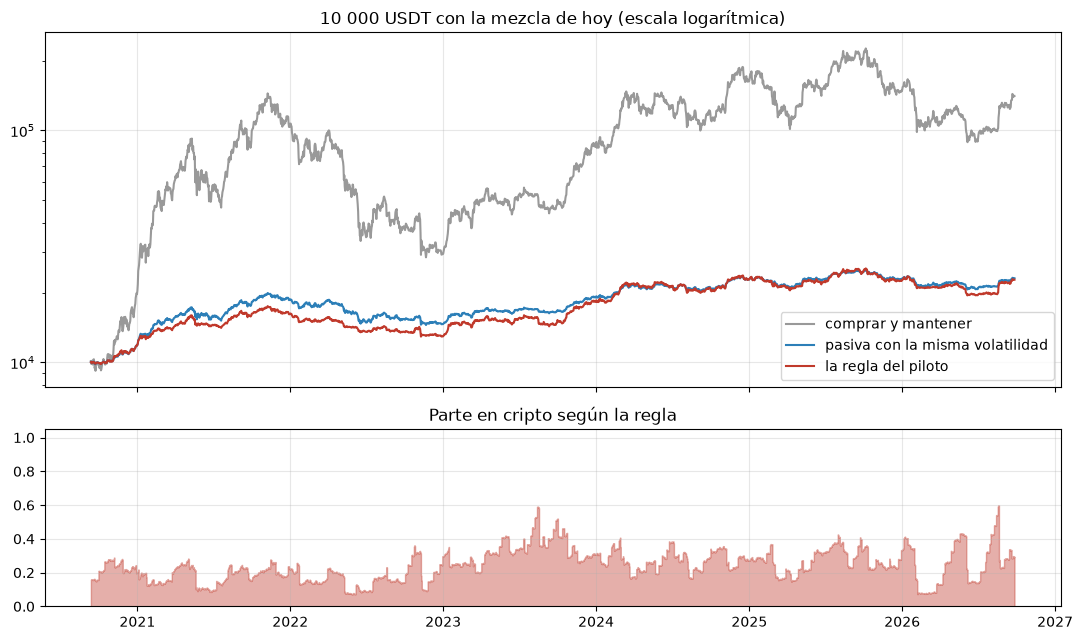

In [10]:
fig, ejes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for col, nombre, color in [("pasiva", "comprar y mantener", "#999999"), ("pasiva_igual_vol", "pasiva con la misma volatilidad", "#2c7fb8"),
                           ("estrategia", "la regla del piloto", "#c0392b")]:
    ejes[0].plot((1 + t[col]).cumprod() * 10_000, label=nombre, color=color)
ejes[0].set_yscale("log"); ejes[0].legend(); ejes[0].set_title("10 000 USDT con la mezcla de hoy (escala logarítmica)")
ejes[1].fill_between(t.index, t["exposicion"], color="#c0392b", alpha=0.4, step="post")
ejes[1].set_ylim(0, 1.05); ejes[1].set_title("Parte en cripto según la regla")
plt.tight_layout(); plt.show()

**Cómo se lee:**
- **Comprar y mantener** ganó muchísimo más en este periodo (un 55 % anual), con una volatilidad del
  65 % y una caída del 80 %. Pocas personas aguantan eso sin vender en el peor momento.
- **La regla** se movió justo el 15 % que se le pidió, con una caída máxima del 26 %, y operó unas dos
  veces al mes gracias a la banda.
- Frente a la **pasiva con la misma volatilidad**, la comparación justa, la regla queda parecida: unas
  décimas menos de rentabilidad y un punto menos de caída máxima. El piloto no promete ganar más:
  promete que tu cartera se mueva lo que elegiste. Es lo que concluye la
  tesis en 8 criptoactivos: reducir el riesgo, sí (HE3); ganar más que la pasiva con el mismo riesgo,
  no demostrado (HE4).

## 5. Más ajustes: qué cambia cada perilla

El piloto deja cambiar los valores de fábrica en **Más ajustes**. Simulemos algunas variantes con la
mezcla de hoy.

In [11]:
variantes = {
    "de fábrica (Prudente)": {},
    "Moderado (25 %)": {"objetivo": 0.25},
    "Decidido (40 %)": {"objetivo": 0.40},
    "sin banda": {"banda": 0.0},
    "sin freno": {"freno_minimo": 1.0},
    "λ = 0,97 (más lenta)": {"lam": 0.97},
}
filas = {}
for nombre, cambios in variantes.items():
    tv = simular(mezcla, {**AJUSTES, **cambios})
    fila = resumen(tv).loc["la regla del piloto"]
    filas[nombre] = {**fila.drop("10 000 USDT se convierten en").round(3).to_dict(),
                     "exposición media": round(tv["exposicion"].mean(), 3), "operaciones": int((tv["giro"] > 0).sum())}
pd.DataFrame(filas).T.astype({"operaciones": int})

,rentabilidad anual,volatilidad,caída máxima,Sharpe,exposición media,operaciones
de fábrica (Prudente),0.145,0.150,-0.261,0.983,0.245,145
Moderado (25 %),0.235,0.225,-0.334,1.052,0.364,252
Decidido (40 %),0.327,0.306,-0.432,1.078,0.472,437
sin banda,0.154,0.152,-0.264,1.022,0.254,2206
sin freno,0.149,0.157,-0.280,0.961,0.260,137
"λ = 0,97 (más lenta)",0.163,0.146,-0.250,1.105,0.239,72


- Subir el **objetivo** sube la volatilidad, la caída y, en este periodo alcista, la rentabilidad.
- **Sin banda**, la regla opera casi todos los días (más de 2000 veces) para un resultado parecido: la
  banda ahorra costes y trabajo.
- **Sin freno** (mínimo del freno = 1, es decir, nunca frena), la caída máxima empeora unos 2 puntos y lo
  demás apenas cambia: el control de volatilidad ya recorta en las caídas, porque las caídas fuertes
  vienen con volatilidad alta.
- Con **λ = 0,97** sale algo mejor en este periodo y opera la mitad. ¿Habría que cambiar el valor de
  fábrica? Elegir el ajuste que mejor le fue al pasado es **sobreajustar** (Unidad 7). La tesis fijó sus
  parámetros antes de mirar los resultados, en un protocolo registrado, justo para evitarlo.

## 6. Mi diario: cuánto has ganado, sin contar ingresos

Supón que guardaste la cartera de ejemplo el 01-03-2026 y, el 01-07-2026, ingresaste 1000 USDT más. Si
miras solo el valor, el ingreso parece una ganancia de 1000. El piloto **encadena rentabilidades**:
cada día valora las unidades que tenías la víspera con los precios de ayer y de hoy, y multiplica. Así
un ingreso no cuenta como ganancia ni un retiro como pérdida. (Es la "rentabilidad ponderada en el
tiempo" que usan los fondos.)

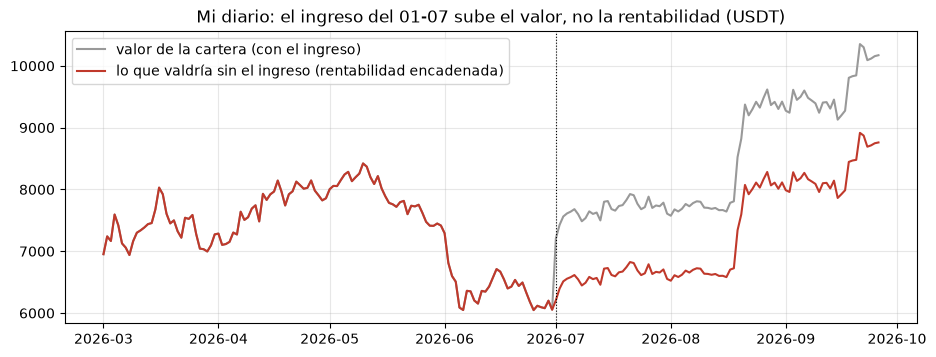

Valor: 6,952 -> 10,171 USDT | rentabilidad real: +26.0%
Caída desde el máximo de 180 días: -1.7% -> freno 1.00


In [12]:
fotos = [{"fecha": "2026-03-01", "tenencias": {"BTC": 0.05, "ETH": 1.2, "SOL": 10.0, "USDT": 500.0}},
         {"fecha": "2026-07-01", "tenencias": {"BTC": 0.05, "ETH": 1.2, "SOL": 10.0, "USDT": 1500.0}}]


def valorar(tenencias, dia):
    return sum(u if a in ESTABLES else u * precios_hist.at[dia, a] for a, u in tenencias.items())


dias = precios_hist.loc[pd.Timestamp(fotos[0]["fecha"], tz="UTC"):].index
indice, saldo = [1.0], [valorar(fotos[0]["tenencias"], dias[0])]
for ayer, hoy in zip(dias[:-1], dias[1:]):
    vigente = [f for f in fotos if pd.Timestamp(f["fecha"], tz="UTC") < hoy][-1]["tenencias"]   # las de la víspera
    indice.append(indice[-1] * valorar(vigente, hoy) / valorar(vigente, ayer))
    actual = [f for f in fotos if pd.Timestamp(f["fecha"], tz="UTC") <= hoy][-1]["tenencias"]
    saldo.append(valorar(actual, hoy))
diario = pd.DataFrame({"valor (USDT)": saldo, "rentabilidad encadenada": indice}, index=dias)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(diario["valor (USDT)"], label="valor de la cartera (con el ingreso)", color="#999999")
ax.plot(diario["valor (USDT)"].iloc[0] * diario["rentabilidad encadenada"], color="#c0392b",
        label="lo que valdría sin el ingreso (rentabilidad encadenada)")
ax.axvline(pd.Timestamp("2026-07-01", tz="UTC"), color="black", linewidth=0.8, linestyle=":")
ax.set_title("Mi diario: el ingreso del 01-07 sube el valor, no la rentabilidad (USDT)")
ax.legend(loc="upper left"); plt.show()

caida = diario["rentabilidad encadenada"].iloc[-1] / diario["rentabilidad encadenada"].iloc[-180:].max() - 1
print(f"Valor: {diario['valor (USDT)'].iloc[0]:,.0f} -> {diario['valor (USDT)'].iloc[-1]:,.0f} USDT"
      f" | rentabilidad real: {diario['rentabilidad encadenada'].iloc[-1] - 1:+.1%}")
print(f"Caída desde el máximo de 180 días: {caida:.1%} -> freno {factor_freno(caida):.2f}")

El valor sube por el ingreso, pero la rentabilidad encadenada no lo cuenta. Y esa rentabilidad es la
que usa el freno: si la caída pasara del 10 %, la recomendación de la sección 2 bajaría.

## 7. Contraste con el código del piloto

Si ejecutas este cuaderno dentro de la carpeta del proyecto `cryptoquant`, esta celda compara cada
cifra con la que calcula el motor de la app (`cryptoquant/piloto/motor.py`). En Colab no está el código
de la app y la celda solo lo avisa.

In [13]:
import sys
from pathlib import Path

raiz = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "cryptoquant" / "piloto" / "motor.py").exists()), None)
if raiz is None:
    print("No encuentro el código del piloto: el contraste solo se puede hacer en tu copia del proyecto.")
else:
    sys.path.insert(0, str(raiz))
    from cryptoquant.laboratorio import control
    from cryptoquant.piloto import motor

    plan = motor.decidir(tenencias, precio.to_dict(), precios_hist)
    comprobaciones = {
        "volatilidad prevista": np.isclose(plan.sigma_prevista, sigma.iloc[-1]),
        "parte en cripto": np.isclose(plan.exposicion_objetivo, exposicion),
        "cantidad a mover": np.isclose(plan.mover, mover),
        "unidades objetivo": np.allclose(plan.ordenes["unidades_objetivo"], ordenes["unidades_objetivo"]),
        "peso en riesgo": np.allclose(plan.riesgo["peso_riesgo"], riesgo["peso en riesgo"]),
        "peores tramos": np.allclose(motor.escenarios(precios_hist, valor.to_dict(), efectivo)["perdida"],
                                     peor["pérdida USDT"].astype(float)),
        "un mal día": np.isclose(motor.mal_dia(precios_hist, valor.to_dict(), efectivo)["var_pct"], mal_dia(valor, efectivo)[0]),
        "próximo mes": np.isclose(motor.proximo_mes(precios_hist, valor.to_dict(), efectivo)["prob_caida_10"],
                                  prob_caer_mes(valor, efectivo)[0]),
    }
    vc = motor.valor_cuenta([{"fecha_utc": f["fecha"], "tenencias": f["tenencias"]} for f in fotos], precios_hist)
    comprobaciones["mi diario"] = np.allclose(vc.to_numpy(), diario["rentabilidad encadenada"].to_numpy())
    tm = motor.simular(precios_hist, mezcla.to_dict())
    comprobaciones["la regla en el pasado"] = np.allclose(tm["estrategia"], t["estrategia"])
    comprobaciones["resumen de la simulación"] = np.allclose(control.resumen(tm).iloc[:, :4].to_numpy(), resumen(t).iloc[:, :4].to_numpy())
    for que, ok in comprobaciones.items():
        print(f"[{'OK' if ok else 'DISTINTO'}] {que}")

[OK] volatilidad prevista
[OK] parte en cripto
[OK] cantidad a mover
[OK] unidades objetivo
[OK] peso en riesgo
[OK] peores tramos
[OK] un mal día
[OK] próximo mes
[OK] mi diario
[OK] la regla en el pasado
[OK] resumen de la simulación


Todas las cifras coinciden: lo que hace la app no es una caja negra, son las ideas de estas nueve
unidades. El cuaderno de R de esta unidad llega a las mismas (salvo el Monte Carlo, que usa otro
generador de azar).

## 8. Lo que el piloto no hace

- **No predice el precio** (unidades 5 y 7). Solo prevé cuánto se moverá.
- **No opera por ti.** No se conecta a tu cuenta ni tiene claves: recomienda, y tú decides.
- **No garantiza nada.** Las simulaciones usan el pasado; el futuro puede traer algo peor que lo peor
  que ya pasó.
- **"Comprar y mantener"** en el piloto es tu reparto rebalanceado cada día y sin costes. Con una sola
  moneda es exactamente comprar y mantener; con varias, es una referencia, no lo que habría hecho
  alguien que compró y no tocó nada.

## Ejercicios

1. **Tu cartera.** Cambia `tenencias` por tu cartera (o una inventada) y repite todo. ¿Cuánto recomienda
   tener en cripto? ¿Qué moneda aporta más riesgo del que pesa?
2. **Igual riesgo por moneda.** El piloto ofrece el reparto "igual riesgo por moneda": cada moneda pesa
   $1/\sigma_i$, normalizado. Calcula esos pesos con la diagonal de la covarianza EWMA y simula la regla.
   ¿Mejora a la mezcla de hoy?
3. **Una sola moneda.** Simula la regla con solo BTC (`mezcla = pd.Series({"BTC": 1.0})`). ¿Cuánto se
   parecen "comprar y mantener" y la pasiva con la misma volatilidad?
4. **El piloto de verdad.** Si tienes el proyecto instalado, guarda esta cartera en la app (o ejecuta
   `python -m cryptoquant piloto --texto`) y compara sus cifras con las de este cuaderno. ¿Por qué no
   son exactamente iguales? (Pista: precios de ahora y cierres hasta ayer.)